In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px  # Interface haut niveau pour graphiques simples
import plotly.graph_objects as go  # Interface bas niveau pour contrôle précis
import seaborn as sns
from plotly.subplots import make_subplots  # Création de grilles de graphiques

#Affichage complet des colonnes et des lignes (pas de retour a la ligne)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.expand_frame_repr", False)

#Import du fichier csv customer
url = "./../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url,sep=",")

# Affichage des dimension du jeu de données
print(f"Le jeu de données a {df.shape[0]} lignes et {df.shape[1]} colonnes")

# Affichez les 5 premières lignes
print(df.head())


Il y a des manquant sur TotalCharges
Passage du types str au type float. (elle est en str mais il n'y a que des floats, elle doit etre en Float)


In [ ]:
# Convertir en numérique
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Vérifier
print("NaN TotalCharges:", df["TotalCharges"].isna().sum())  # devrait afficher 11
print(df["TotalCharges"].dtype)  # float64 attendu

#affichage des lignes avec des valeurs manquantes
print(df[df["TotalCharges"].isna()])

NaN TotalCharges: 11
float64
      customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService       OnlineSecurity         OnlineBackup     DeviceProtection          TechSupport          StreamingTV      StreamingMovies  Contract PaperlessBilling              PaymentMethod  MonthlyCharges  TotalCharges Churn
488   4472-LVYGI  Female              0     Yes        Yes       0           No  No phone service             DSL                  Yes                   No                  Yes                  Yes                  Yes                   No  Two year              Yes  Bank transfer (automatic)           52.55           NaN    No
753   3115-CZMZD    Male              0      No        Yes       0          Yes                No              No  No internet service  No internet service  No internet service  No internet service  No internet service  No internet service  Two year               No               Mailed check           20.25  

Recherche correlation avec les autre colonnes numerique

TotalCharges      1.000000
tenure            0.825880
MonthlyCharges    0.651065
SeniorCitizen     0.102411
Name: TotalCharges, dtype: float64


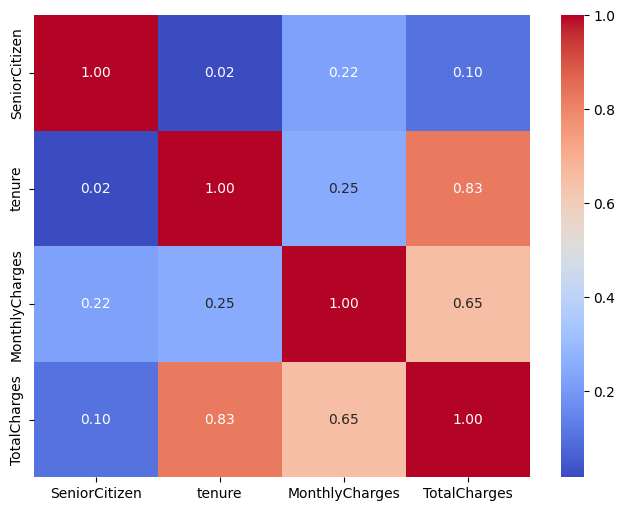

In [ ]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix["TotalCharges"].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

On voit une correlation avec tenure (0.83) et MonthlyCharge (0.65. moins mais quand meme)
si on regarde les c'est 2 colonnes on peut voir que tenure x MonthlyCharge et tres proche de totalCharges 
=> remplir les manquants de TotalCharges par tenure x MonthlyCharge. Dans notre cas tenure = 0 pour les manquant donc c'est normale de ne rien avoir
 je pourrais directement mettre 0 dans TotalCharges mais pour le fun je fais le calcul

In [ ]:
#remplace les valeurs manquantes par tenure* MonthlyCharges
mask = df["TotalCharges"].isna()
df.loc[mask, "TotalCharges"] = df.loc[mask, "tenure"] * df.loc[mask, "MonthlyCharges"]

print(df.loc[mask].to_string())

# verification des manquants
if (df.isna().sum() == 0).all():
    print("Il ne manque aucune valeur maintenant.")
else:
    print("Il y a ENCORE des valeurs manquantes.")
    print(f"{df.isna().sum()}")  
    

      customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService       OnlineSecurity         OnlineBackup     DeviceProtection          TechSupport          StreamingTV      StreamingMovies  Contract PaperlessBilling              PaymentMethod  MonthlyCharges  TotalCharges Churn
488   4472-LVYGI  Female              0     Yes        Yes       0           No  No phone service             DSL                  Yes                   No                  Yes                  Yes                  Yes                   No  Two year              Yes  Bank transfer (automatic)           52.55           0.0    No
753   3115-CZMZD    Male              0      No        Yes       0          Yes                No              No  No internet service  No internet service  No internet service  No internet service  No internet service  No internet service  Two year               No               Mailed check           20.25           0.0    No
936   5709